<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/HPVvalidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE



In [2]:
df = pd.read_excel("HPVMODEL5.xlsx")

In [3]:
df.head ()

,PatientID,CenterID,Task 1,Task 2,Task 3,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,T-stage,N-stage,M-stage,HPV Status,Relapse,RFS
0,CHUM-001,1,1,1,0,82.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1704.0
1,CHUM-002,1,1,1,0,73.0,1,NaN,NaN,NaN,1.0,T3,N2,M0,NaN,1.0,439.0
2,CHUM-006,1,1,1,0,65.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1186.0
3,CHUM-007,1,1,1,0,70.0,0,NaN,NaN,NaN,0.0,T2,N2,M0,NaN,0.0,1702.0
4,CHUM-008,1,1,1,0,67.0,0,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1499.0


In [4]:
df.isnull().sum()

,0
PatientID,0
CenterID,0
Task 1,0
Task 2,0
Task 3,0
Age,0
Gender,0
Tobacco Consumption,212
Alcohol Consumption,218
Performance Status,263


In [5]:
df = df.dropna(subset=['HPV Status'])

In [6]:
tobacco_mode = df['Tobacco Consumption'].mode()[0]

df['Tobacco Consumption'] = df['Tobacco Consumption'].fillna(tobacco_mode)

In [7]:
alcohol_mode = df['Alcohol Consumption'].mode()[0]

df['Alcohol Consumption'] = df['Alcohol Consumption'].fillna(alcohol_mode)

In [8]:
df = df.drop(
    columns=[
        'Performance Status',
        'Relapse',
        'RFS',
        'PatientID',
        'CenterID',
        'Task 1',
        'Task 2',
        'Task 3'
    ]
)

In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Tobacco Consumption,0
Alcohol Consumption,0
Treatment,19
T-stage,3
N-stage,2
M-stage,2
HPV Status,0


In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

,0
Age,0
Gender,0
Tobacco Consumption,0
Alcohol Consumption,0
Treatment,0
T-stage,0
N-stage,0
M-stage,0
HPV Status,0


In [12]:
df.shape

(562, 9)

In [13]:
df['T-stage'] = df['T-stage'].replace({
    'T0':0,
    'T1':1,
    'T2':2,
    'T3':3,
    'T4':4
})

/tmp/ipykernel_6153/630066328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['T-stage'] = df['T-stage'].replace({


In [14]:
df['N-stage'] = df['N-stage'].replace({
    'N0':0,
    'N1':1,
    'N2':2,
    'N3':3
})

/tmp/ipykernel_6153/622728836.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['N-stage'] = df['N-stage'].replace({


In [15]:
df['M-stage'] = df['M-stage'].replace({
    'M0':0,
    'M1':1
})

/tmp/ipykernel_6153/752138774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['M-stage'] = df['M-stage'].replace({


In [16]:
print(df['T-stage'].unique())
print(df['N-stage'].unique())
print(df['M-stage'].unique())

[2 4 3 1 0]
[1 2 3 0]
[0 1]


In [17]:
X = df[
    [
        'Age',
        'Gender',
        'Tobacco Consumption',
        'Alcohol Consumption',
        'Treatment',
        'T-stage',
        'N-stage',
        'M-stage'
    ]
]

y = df['HPV Status']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [65]:
print(X_train.shape)
print(X_test.shape)

(449, 8)
torch.Size([113, 8])


In [66]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [67]:
print(X_train_final.shape)
print(X_val.shape)

(359, 8)
(90, 8)


In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train_final
)

In [70]:
print(
    pd.Series(y_train_smote).value_counts()
)

HPV Status
1.0    325
0.0    325
Name: count, dtype: int64


In [72]:
print(type(y_test))
print(type(y_val))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [73]:
import torch

# Training data from SMOTE
X_train_smote = torch.tensor(
    X_train_smote,
    dtype=torch.float32
)

y_train_smote = torch.tensor(
    y_train_smote,
    dtype=torch.long
)

# Validation data
if not isinstance(X_val, torch.Tensor):
    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    )

if not isinstance(y_val, torch.Tensor):
    y_val = torch.tensor(
        y_val,
        dtype=torch.long
    )
else:
    y_val = y_val.long()

# Test data
if not isinstance(X_test, torch.Tensor):
    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

if not isinstance(y_test, torch.Tensor):
    y_test = torch.tensor(
        y_test,
        dtype=torch.long
    )
else:
    y_test = y_test.long()

/tmp/ipykernel_6153/3855315848.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_smote = torch.tensor(
/tmp/ipykernel_6153/3855315848.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_smote = torch.tensor(


In [74]:
print(type(X_train_smote))
print(type(X_val))
print(type(X_test))

print(type(y_train_smote))
print(type(y_val))
print(type(y_test))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [75]:
import torch.nn as nn

class HPVNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(8, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

In [76]:
model = HPVNet()

weights = torch.tensor(
    [3.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [77]:
train_losses = []

val_losses = []

epochs = 500

best_val_loss = float('inf')

best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_smote)

    train_loss = criterion(
        outputs,
        y_train_smote
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val)

        val_loss = criterion(
            val_outputs,
            y_val
        )

    train_losses.append(
        train_loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            'best_validation_model.pth'
        )

    if (epoch + 1) % 50 == 0:

        print(
            f'Epoch {epoch+1}, '
            f'Train Loss={train_loss.item():.4f}, '
            f'Val Loss={val_loss.item():.4f}'
        )

print("Best Validation Loss =", best_val_loss)
print("Best Epoch =", best_epoch)

Epoch 50, Train Loss=0.4396, Val Loss=0.8077
Epoch 100, Train Loss=0.2656, Val Loss=0.5521
Epoch 150, Train Loss=0.1979, Val Loss=0.5012
Epoch 200, Train Loss=0.1617, Val Loss=0.4742
Epoch 250, Train Loss=0.1267, Val Loss=0.4617
Epoch 300, Train Loss=0.0980, Val Loss=0.5015
Epoch 350, Train Loss=0.0750, Val Loss=0.5712
Epoch 400, Train Loss=0.0593, Val Loss=0.6503
Epoch 450, Train Loss=0.0494, Val Loss=0.7461
Epoch 500, Train Loss=0.0427, Val Loss=0.8577
Best Validation Loss = 0.460833877325058
Best Epoch = 241


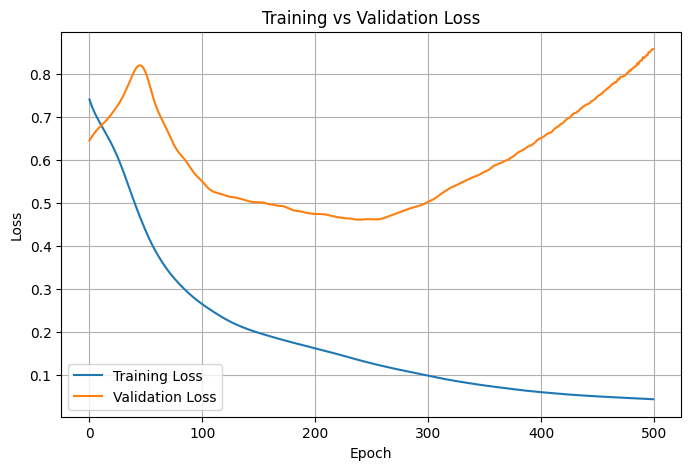

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label='Training Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Training vs Validation Loss'
)

plt.legend()

plt.grid(True)

plt.show()

In [79]:
model.load_state_dict(
    torch.load(
        'best_validation_model.pth'
    )
)

<All keys matched successfully>

In [80]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [81]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.24      0.29      0.26        14
           1       0.90      0.87      0.88        99

    accuracy                           0.80       113
   macro avg       0.57      0.58      0.57       113
weighted avg       0.81      0.80      0.80       113



In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

print(cm)


[[ 4 10]
 [13 86]]


In [83]:
from sklearn.metrics import roc_auc_score

with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(
        outputs,
        dim=1
    )

    hpv_positive_probs = probs[:,1]

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.7016594516594518
